In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from scipy.stats import randint, uniform

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

In [198]:
df = pd.read_csv("../dataset/student.csv")
print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully: 1044 rows, 33 columns


In [199]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [200]:
for col in ["Mjob", "Fjob", "reason", "guardian"]:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

df = df.drop(columns=["school", "address"])

df["sex_male"] = df["sex"] == "M"
df["parent_together"] = df["Pstatus"] == "T"
df["famsize_large"] = df["famsize"] == "GT3"

mapping = {1: 60, 2: 210, 3: 450, 4: 720}
df["traveltime_minutes"] = df["traveltime"].map(mapping)
df["studytime_minutes"] = df["studytime"].map(mapping)

for col in ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]:
    df[col] = (df[col] == "yes").astype(int)

for col in ["G1", "G2", "G3"]:
    df[col] = df[col] * 5

df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
df["total_support"] = df[["schoolsup", "famsup", "paid"]].sum(axis=1)
df["study_per_travel"] = df["studytime_minutes"] / (df["traveltime_minutes"] + 1)

df = df.drop(columns=["schoolsup", "Pstatus", "famsup", "paid", "studytime_minutes", "traveltime_minutes", "studytime", "Medu", "Fedu", "sex", "famsize"])

In [201]:
df.head()

,age,traveltime,failures,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,sex_male,parent_together,famsize_large,avg_parent_edu,total_support,study_per_travel
0,18,2,0,0,1,1,0,0,4,3,4,1,1,3,6,25,30,30,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,4.0,1,0.995261
1,17,1,0,0,0,1,1,0,5,3,3,1,1,3,4,25,25,30,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,True,1.0,1,3.442623
2,15,1,3,0,1,1,1,0,4,3,2,2,3,3,10,35,40,50,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,1.0,2,3.442623
3,15,1,0,1,1,1,1,1,3,2,2,1,1,5,2,75,70,75,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,True,3.0,2,7.377049
4,16,1,0,0,1,1,0,0,4,3,2,1,2,5,4,30,50,50,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,True,True,3.0,2,3.442623


In [202]:
X = df.drop(columns=["G3"]).select_dtypes(include=[np.number])
y = df["G3"]

selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1), 
    threshold="median"
)
selector.fit(X, y)
X_selected = selector.transform(X)
print(f"Selected {X_selected.shape[1]} features from {X.shape[1]} total features")

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Selected 10 features from 20 total features


In [203]:
rf_params = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 25),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_params,
    n_iter=25,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=2,
    random_state=42,
    verbose=0
)
rf_search.fit(X_train, y_train)

# Use the best model found
model = rf_search.best_estimator_
print("====================RandomForestRegressor=====================")
print(f"Best CV RMSE: {np.sqrt(-rf_search.best_score_):.4f}")

# Evaluate on test set
y_pred = model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
print(f"Test RMSE: {rf_rmse:.4f}")
print(f"Test R²: {rf_r2:.4f}")
print(f"Test MAE: {rf_mae:.4f}")

y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {rf_r2:.4f}")

# Check for overfitting
overfitting_gap = train_r2 - rf_r2
if overfitting_gap > 0.15:
    print(f"Potential overfitting detected: {overfitting_gap:.4f} gap between train and test R²")
else:
    print(f"Model generalization is good: {overfitting_gap:.4f} gap")

def regression_accuracy(y_true, y_pred, tolerance=5):
    correct = abs(y_true - y_pred) <= tolerance
    return correct.mean() * 100

acc_5 = regression_accuracy(y_test, y_pred, tolerance=5)
acc_10 = regression_accuracy(y_test, y_pred, tolerance=10)

print(f"Accuracy: {acc_5:.2f}%")
print(f"Accuracy: {acc_10:.2f}%")

====================RandomForestRegressor=====================
Best CV RMSE: 7.0781
Test RMSE: 8.2150
Test R²: 0.8254
Test MAE: 4.5763
Train R²: 0.9106
Test R²: 0.8254
Model generalization is good: 0.0852 gap
Accuracy: 70.33%
Accuracy: 92.34%


In [204]:
# XGBoost hyperparameter search space
xgb_param_dist = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 2)
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1, verbosity=0),
    xgb_param_dist,
    n_iter=25,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=2,
    random_state=42,
    verbose=0
)
xgb_search.fit(X_train, y_train)

# Use the best model found
xgb_model = xgb_search.best_estimator_
print("====================XGBoost=====================")
print(f"Best CV RMSE: {np.sqrt(-xgb_search.best_score_):.4f}")

# Evaluate on test set
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"Test RMSE: {xgb_rmse:.4f}")
print(f"Test R²: {xgb_r2:.4f}")
print(f"Test MAE: {xgb_mae:.4f}")

====================XGBoost=====================
Best CV RMSE: 7.1942
Test RMSE: 8.0887
Test R²: 0.8307
Test MAE: 4.7086


In [205]:
print("\n=== MODEL COMPARISON ===")
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'R²': [rf_r2, xgb_r2],
    'MAE': [rf_mae, xgb_mae]
})

print(comparison.to_string(index=False))
best_model = 'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'
print(f"\nBest model: {best_model}")


=== MODEL COMPARISON ===
        Model     RMSE       R²      MAE
Random Forest 8.215025 0.825400 4.576263
      XGBoost 8.088684 0.830729 4.708554

Best model: XGBoost


In [206]:
# Select the best model based on R² (highest is best)
best_model_r2 = max(rf_r2, xgb_r2)
if rf_r2 > xgb_r2:
    best_estimator = model  # RF model
    best_predictions = y_pred
    best_model_name = 'Random Forest (Optimized)'
    best_model_rmse = rf_rmse
    best_model_mae = rf_mae
    is_rf = True
else:
    best_estimator = xgb_model  # XGB model
    best_predictions = xgb_pred
    best_model_name = 'XGBoost'
    best_model_rmse = xgb_rmse
    best_model_mae = xgb_mae
    is_rf = False

print(f"\nBEST MODEL: {best_model_name}")
print(f"   RMSE: {best_model_rmse:.4f}")
print(f"   R²: {best_model_r2:.4f}")
print(f"   MAE: {best_model_mae:.4f}")
print(f"   Type: {'Random Forest' if is_rf else 'XGBoost'}")


BEST MODEL: XGBoost
   RMSE: 8.0887
   R²: 0.8307
   MAE: 4.7086
   Type: XGBoost


Top features by average SHAP impact:


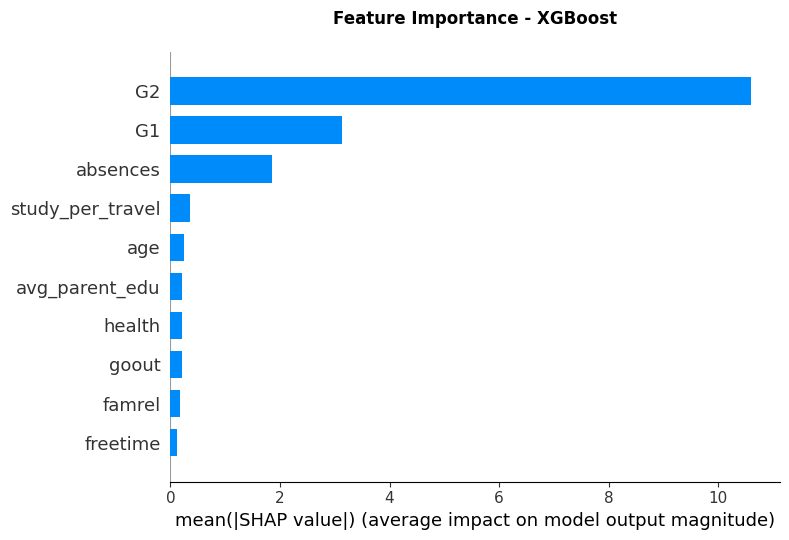


Feature impact on predictions:


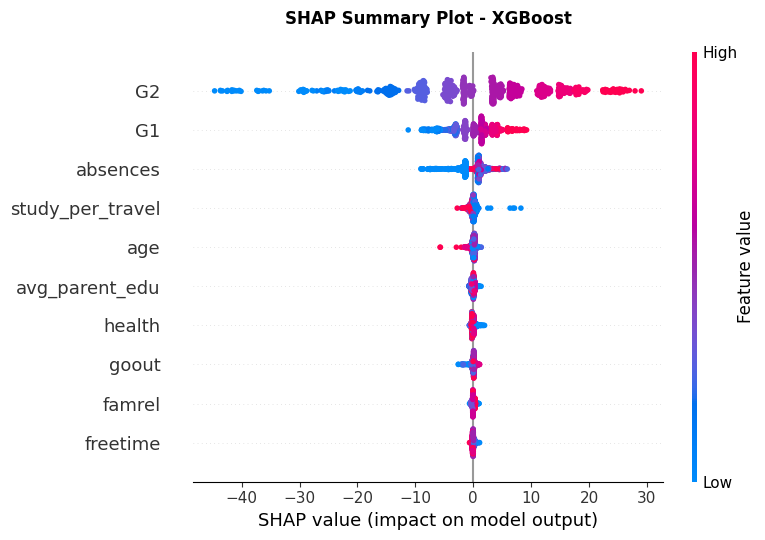

In [207]:
# Get feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
X_train_df = pd.DataFrame(X_train, columns=selected_features)
X_test_df = pd.DataFrame(X_test, columns=selected_features)

# Create explainer based on model type
if is_rf:
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value
else:
    # For XGBoost
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value

# Summary plot - Feature importance
print("Top features by average SHAP impact:")
shap.summary_plot(shap_values_best, X_train_df, plot_type="bar", show=False)
plt.title(f"Feature Importance - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nFeature impact on predictions:")
shap.summary_plot(shap_values_best, X_train_df, show=False)
plt.title(f"SHAP Summary Plot - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Explaining predictions from XGBoost...

Sample Predictions (first 5):
Actual    Predicted   Error     
--------------------------------
55.00     50.79       4.21      
40.00     41.51       1.51      
65.00     67.48       2.48      
55.00     55.38       0.38      
60.00     63.00       3.00      


SHAP Force Plot - Sample #1:
Actual value: 55.00
Predicted value: 53.49
(Base value = model's average prediction. Red = increases prediction, Blue = decreases)



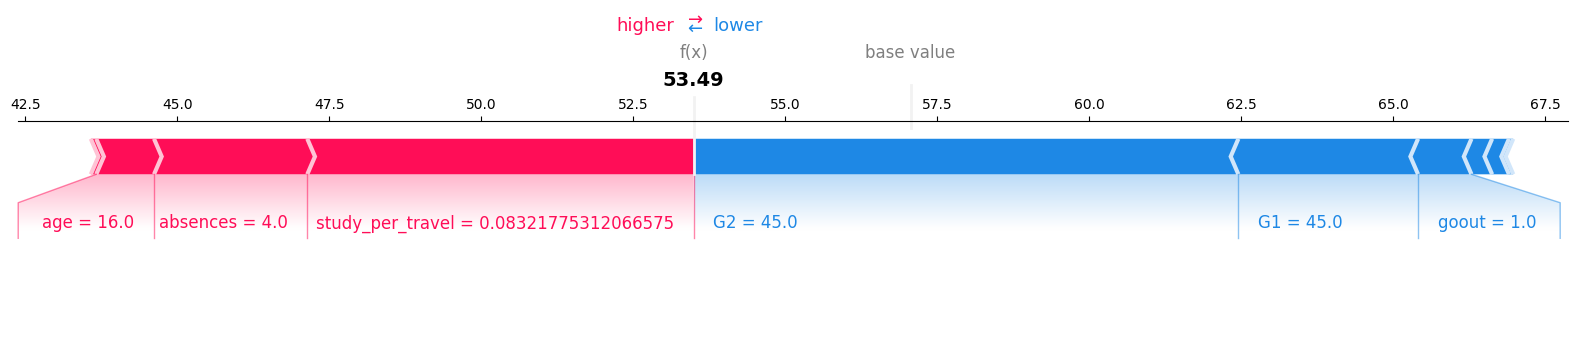

<Figure size 640x480 with 0 Axes>



Top Contributing Factors for Sample #1:
------------------------------------------------------------
 1. G2                        ↓ decreases     (-8.9606)
 2. study_per_travel          ↑ increases     (+6.3517)
 3. G1                        ↓ decreases     (-2.9552)
 4. absences                  ↑ increases     (+2.5206)
 5. age                       ↑ increases     (+0.9505)
 6. goout                     ↓ decreases     (-0.8787)
 7. health                    ↓ decreases     (-0.3394)
 8. famrel                    ↓ decreases     (-0.2775)
 9. freetime                  ↑ increases     (+0.0889)
10. avg_parent_edu            ↓ decreases     (-0.0698)


In [208]:
print(f"Explaining predictions from {best_model_name}...\n")

# Show predictions vs actual for a few samples
print("Sample Predictions (first 5):")
print(f"{'Actual':<10}{'Predicted':<12}{'Error':<10}")
print("-" * 32)
for i in range(min(5, len(y_test))):
    actual = y_test.iloc[i]
    pred = best_predictions[i]
    error = abs(actual - pred)
    print(f"{actual:<10.2f}{pred:<12.2f}{error:<10.2f}")

# SHAP force plot for first sample
print(f"\n\nSHAP Force Plot - Sample #1:")
print(f"Actual value: {y_train.iloc[0]:.2f}")
print(f"Predicted value: {best_estimator.predict(X_train_df.iloc[0:1])[0]:.2f}")
print("(Base value = model's average prediction. Red = increases prediction, Blue = decreases)\n")

shap.force_plot(
    expected_value,
    shap_values_best[0],
    X_train_df.iloc[0],
    matplotlib=True
)
plt.tight_layout()
plt.show()

# Detailed explanation
def explain_prediction_detailed(shap_vals, features, threshold=0.01):
    """Generate human-readable explanation of prediction contributions."""
    contributions = []
    for i, feat in enumerate(features):
        if abs(shap_vals[i]) > threshold:
            impact = "↑ increases" if shap_vals[i] > 0 else "↓ decreases"
            contributions.append((feat, shap_vals[i], impact))
    
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return contributions

print("\n\nTop Contributing Factors for Sample #1:")
print("-" * 60)
contributions = explain_prediction_detailed(shap_values_best[0], selected_features)
for i, (feat, impact_val, direction) in enumerate(contributions[:10], 1):
    print(f"{i:2}. {feat:<25} {direction:<15} ({impact_val:+.4f})")